In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state



map_path = "/home/paul/Projects/keldysh/metastable/00-attempt/map.npz"
fixed_point_map = FixedPointMap.load(map_path)

Quimb not available.


In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state



map_path = "/home/paul/Projects/keldysh/metastable/00-attempt/map.npz"
fixed_point_map = FixedPointMap.load(map_path)

Quimb not available.


In [2]:
fixed_point_map.path_results[360,80]

       message: The algorithm converged to the desired accuracy.
       success: True
        status: 0
             x: [ 0.000e+00  8.000e-04 ...  7.999e+00  8.000e+00]
           sol: <scipy.interpolate._interpolate.PPoly object at 0x7f45ad8b5a30>
             p: None
             y: [[-7.235e+00 -7.230e+00 ... -2.103e+00 -2.103e+00]
                 [-1.271e+01 -1.271e+01 ...  8.443e+00  8.443e+00]
                 [-5.616e-01 -5.631e-01 ...  1.027e-06  1.025e-06]
                 [-4.672e-01 -4.727e-01 ... -5.759e-07 -5.746e-07]]
            yp: [[ 6.280e+00  6.360e+00 ...  8.954e-07  8.934e-07]
                 [-9.118e+00 -9.147e+00 ... -8.125e-07 -8.107e-07]
                 [-1.941e+00 -1.913e+00 ... -2.854e-06 -2.848e-06]
                 [-6.847e+00 -6.845e+00 ...  1.600e-06  1.596e-06]]
 rms_residuals: [ 2.892e-06  2.918e-06 ...  6.390e-12  4.943e-12]
         niter: 1

In [3]:
def calculate_action(bvp_result):
    
    def integrand_func(t):
        integrand = -bvp_result.sol(t,nu=1)[0]*bvp_result.sol(t)[2]
        integrand -= bvp_result.sol(t,nu=1)[1]*bvp_result.sol(t)[3]
        return integrand

    action, action_error = scipy.integrate.quad(integrand_func, 0, bvp_result.x[-1], limit=2000, epsabs=1e-2)
    return action, action_error

In [4]:
calculate_action(fixed_point_map.path_results[360,80])


(-63.19637741503011, 0.008023275300623744)

In [5]:
actions_array = np.zeros(fixed_point_map.kappa_linspace.shape)

from tqdm import tqdm

for idx in tqdm(range(40, 236)):
    bvp_result = fixed_point_map.path_results[360,idx]
    action, action_error = calculate_action(bvp_result)
    actions_array[idx] = action

  0%|          | 0/196 [00:00<?, ?it/s]/tmp/ipykernel_151990/916303766.py:5: RuntimeWarning: overflow encountered in scalar multiply
  integrand -= bvp_result.sol(t,nu=1)[1]*bvp_result.sol(t)[3]
/tmp/ipykernel_151990/916303766.py:4: RuntimeWarning: overflow encountered in scalar multiply
  integrand = -bvp_result.sol(t,nu=1)[0]*bvp_result.sol(t)[2]
/tmp/ipykernel_151990/916303766.py:8: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  action, action_error = scipy.integrate.quad(integrand_func, 0, bvp_result.x[-1], limit=2000, epsabs=1e-2)
  2%|▏         | 4/196 [00:00<00:06, 30.80it/s]/tmp/ipykernel_151990/916303766.py:8: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  action, action_error = scipy.integrate.quad(integrand_func, 0, bvp_result.x[-1], limit=2000, epsabs=1e-2)
  4%|▍         | 8/196 [00:00<00:06, 3

(-100.0, 10.0)

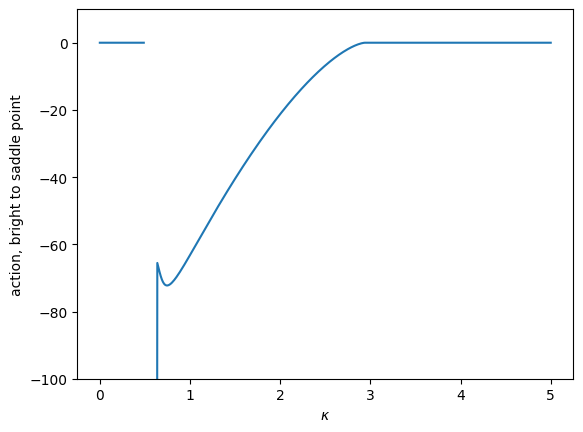

In [6]:
plt.plot(fixed_point_map.kappa_linspace, actions_array)
plt.xlabel(r'$\kappa$')
plt.ylabel(r'action, bright to saddle point')
plt.ylim([-100,10])

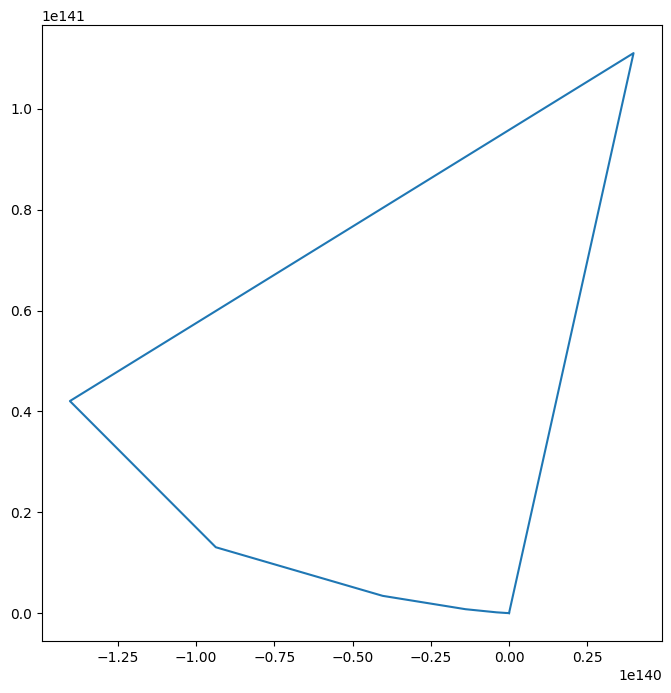

nan
0.4375


/tmp/ipykernel_151990/916303766.py:5: RuntimeWarning: overflow encountered in scalar multiply
  integrand -= bvp_result.sol(t,nu=1)[1]*bvp_result.sol(t)[3]
/tmp/ipykernel_151990/916303766.py:4: RuntimeWarning: overflow encountered in scalar multiply
  integrand = -bvp_result.sol(t,nu=1)[0]*bvp_result.sol(t)[2]
/tmp/ipykernel_151990/916303766.py:8: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  action, action_error = scipy.integrate.quad(integrand_func, 0, bvp_result.x[-1], limit=2000, epsabs=1e-2)


In [7]:
kappa_idx = 35
res = fixed_point_map.path_results[360,kappa_idx]
fig, axes = plt.subplots(1,1,figsize=(8, 8))
t_plot = np.linspace(0, res.x[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()

action, action_error = calculate_action(res)

print(action)
print(fixed_point_map.kappa_linspace[kappa_idx])

In [8]:
fixed_point_map.fixed_points[374,0]

array([[-1.60621279e-15,  7.50963986e+00],
       [-3.19947551e-18, -1.44180269e+01],
       [ 6.20018785e-16,  6.90838699e+00]])

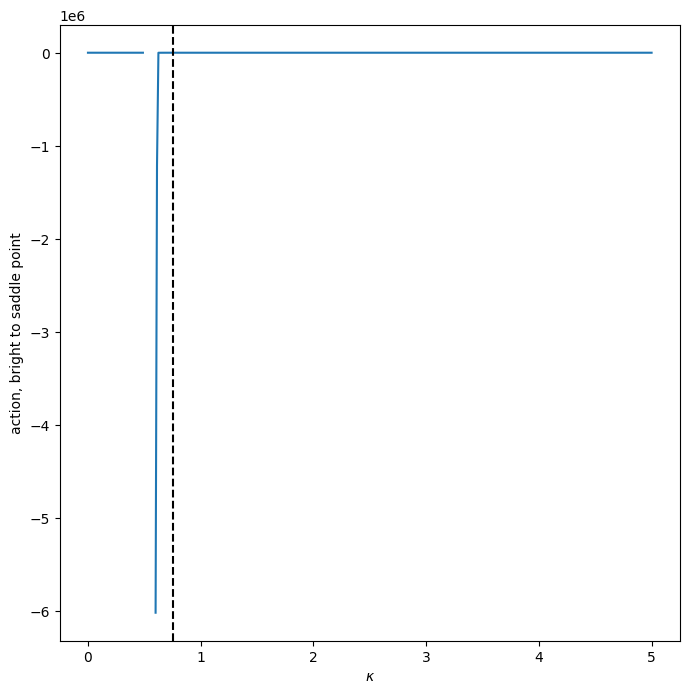

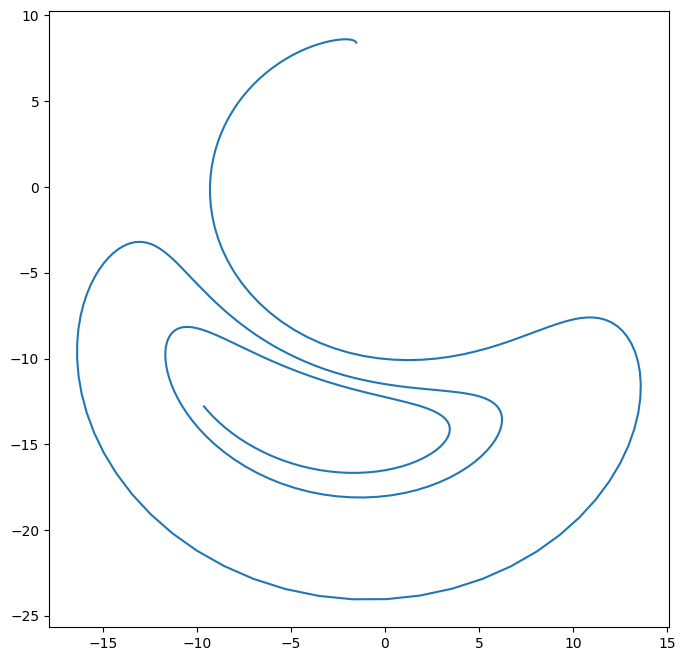

-72.24554109801429
0.75


In [9]:
kappa_idx = 60


fig, axes = plt.subplots(1, 1, figsize=(8, 8))

axes.plot(fixed_point_map.kappa_linspace, actions_array)
axes.set_xlabel(r'$\kappa$')
axes.set_ylabel(r'action, bright to saddle point')

axes.axvline(fixed_point_map.kappa_linspace[kappa_idx], color='k', linestyle='--')

res = fixed_point_map.path_results[360,kappa_idx]

fig, axes = plt.subplots(1,1,figsize=(8, 8))
t_plot = np.linspace(0, res.x[-1], 1001)
y0_plot = res.sol(t_plot)[0]
y1_plot = res.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
plt.show()

action, action_error = calculate_action(res)

print(action)
print(fixed_point_map.kappa_linspace[kappa_idx])